### ⚠️ Audit note — cases_7d_avg leakage gap NOT fixable from this notebook

This notebook builds its feature sets via `get_feature_sets()` / `load_canonical_dataset()`, both **imported from `canonical_pipeline.py`**, whose source was not included in the files reviewed. The same `cases_7d_avg` leakage confirmed in Notebooks 08/09 (r≈0.96-0.99 with same-day `dengue_cases`, not matched by any `case_pfx` prefix) likely also exists inside `get_feature_sets()`, since this notebook's own correlation printout flags `cases_7d_avg` as the single highest-correlated feature with same-day cases.

**Action required**: open `canonical_pipeline.py` and confirm `get_feature_sets()` excludes `cases_7d_avg` (and any other raw, non-prefixed case-derived column) from `rf_features` / `dl_feat_features`. This cannot be patched here because the function body is not in this notebook.

# 01 — Data Preprocessing Analysis & Feature Engineering Analysis — **CORRECTED VERSION**

**Section 4.1.4 items #1 and #2: Data Preprocessing Analysis, Feature Engineering Analysis**

### What changed from the previous version
The previous version of this notebook had its own local `create_features()` function that
produced only **53 features** and was missing an entire family described in Thesis Section
3.2.1/4.2.2 — the **weather lag features** (`temperature_lag14/21`, `rainfall_lag14/21/28`,
`humidity_lag14`) that motivate the "rain → mosquito breeding → bite → illness" lifecycle
argument — plus `temp_range`, and it encoded `day_of_week` as a single integer rather than
matching the documented description. That meant this notebook's output dataset did not match
the 60-feature canonical dataset that every other analysis notebook (08, 09, 10, 11, 12, 13, 14)
is built on, and `Random Forest` here was given the full feature set (including case-history
lags) rather than the fair weather/calendar/population-only subset used everywhere else.

This version imports `engineer_features()` and `get_feature_sets()` directly from
`canonical_pipeline.py` — the same functions Notebook 08 (and everything built on top of it)
uses — so this notebook's output is guaranteed consistent with the rest of the project, and
saves to `processed_data/canonical_data.pkl` (the same file `00_setup_canonical_baselines.ipynb`
produces — running either one is sufficient, and running both is harmless since they call the
identical underlying function).


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, warnings
warnings.filterwarnings('ignore')

os.makedirs('processed_data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('metrics', exist_ok=True)
os.makedirs('plots', exist_ok=True)

from canonical_pipeline import (engineer_features, get_feature_sets, make_scalers,
                                 make_sequences, SEQ_LEN)
print("✅ Directories created, canonical_pipeline imported")


✅ Directories created, canonical_pipeline imported


## 1. Load Raw Data

In [14]:
CSV_PATH = 'singapore_dengue_weather_2013_2022.csv'
df_raw = pd.read_csv(CSV_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f"Dataset: {len(df_raw)} days")
print(f"Range: {df_raw['date'].min().date()} to {df_raw['date'].max().date()}")
print(f"Raw columns ({len(df_raw.columns)}): {list(df_raw.columns)}")

print(f"\n{'Year':>6} | {'Days':>5} | {'Total':>8} | {'Mean':>6} | {'Max':>6}")
print(f"{'─'*6}-+-{'─'*5}-+-{'─'*8}-+-{'─'*6}-+-{'─'*6}")
for yr in sorted(df_raw['date'].dt.year.unique()):
    s = df_raw[df_raw['date'].dt.year == yr]
    print(f"{yr:>6} | {len(s):>5} | {s['dengue_cases'].sum():>8,.0f} | "
          f"{s['dengue_cases'].mean():>6.1f} | {s['dengue_cases'].max():>6.1f}")


Dataset: 3652 days
Range: 2013-01-01 to 2022-12-31
Raw columns (18): ['date', 'dengue_cases', 'temperature', 'temperature_max', 'temperature_min', 'rainfall', 'humidity', 'windspeed', 'windspeed_max', 'day_of_year', 'month', 'year', 'population_density', 'is_rainy_season', 'temperature_7d_avg', 'rainfall_7d_sum', 'humidity_7d_avg', 'cases_7d_avg']

  Year |  Days |    Total |   Mean |    Max
──────-+-─────-+-────────-+-──────-+-──────
  2013 |   365 |   22,193 |   60.8 |  113.2
  2014 |   365 |   18,345 |   50.3 |   93.5
  2015 |   365 |   11,289 |   30.9 |   57.6
  2016 |   366 |   13,276 |   36.3 |   90.9
  2017 |   365 |    2,788 |    7.6 |   13.0
  2018 |   365 |    3,332 |    9.1 |   29.6
  2019 |   365 |   16,069 |   44.0 |   94.7
  2020 |   366 |   35,129 |   96.0 |  256.0
  2021 |   365 |    5,308 |   14.5 |   27.7
  2022 |   365 |   32,186 |   88.2 |  223.9


## 2. Data Preprocessing Analysis

### 2.1 Missing values

In [15]:
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "  None — raw CSV is complete, no imputation needed.")
print(f"\nTotal missing cells: {missing.sum()} / {df_raw.shape[0]*df_raw.shape[1]}")
print("\nNOTE: missing values WILL appear after feature engineering (lag/rolling-window features")
print("      need n prior days of history before they're defined) — these are handled later by")
print("      dropping the lead-in rows, not by imputation, since imputing a lag-28 feature for the")
print("      first 28 rows of a 10-year series would fabricate information, not preserve it.")


Missing values per column:
  None — raw CSV is complete, no imputation needed.

Total missing cells: 0 / 65736

NOTE: missing values WILL appear after feature engineering (lag/rolling-window features
      need n prior days of history before they're defined) — these are handled later by
      dropping the lead-in rows, not by imputation, since imputing a lag-28 feature for the
      first 28 rows of a 10-year series would fabricate information, not preserve it.


### 2.2 Outlier / distribution analysis

Variable             mean      std    skew  IQR_outliers      max
──────────────────────────────────────────────────────────────────────
dengue_cases         43.8     43.3    2.21    217 ( 5.9%)    256.0
temperature          26.7      0.8   -0.31     25 ( 0.7%)     29.1
rainfall              8.0      9.5    4.00    155 ( 4.2%)    152.9
humidity             85.3      4.0   -0.93     86 ( 2.4%)     95.0


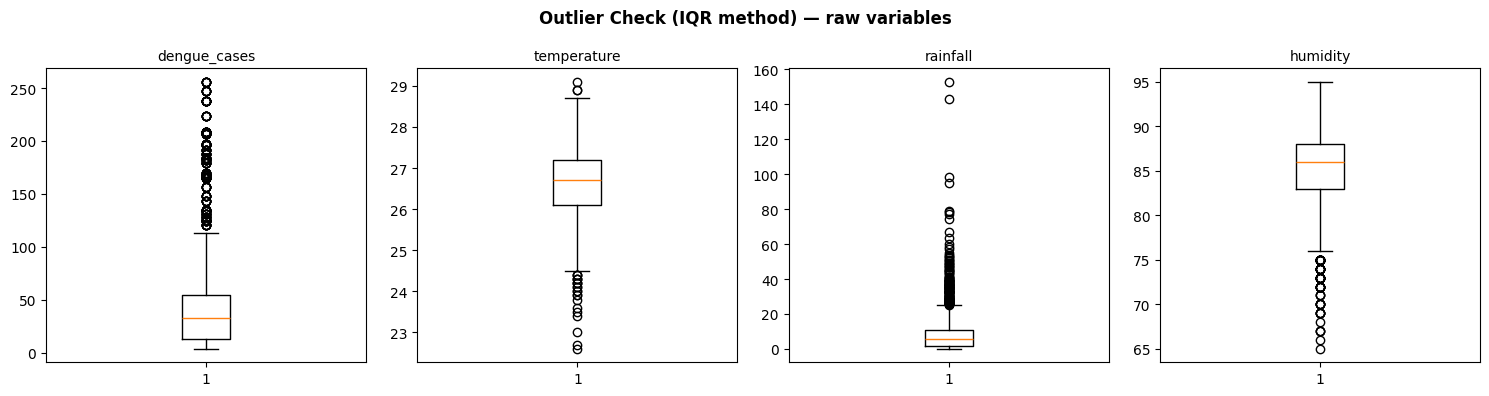


✅ Saved plots/outlier_boxplots.png

INTERPRETATION: dengue_cases is heavily right-skewed (skew>2) with outbreak-period spikes
flagged as IQR outliers (e.g. the 2020 outbreak, max=256/day vs a typical day's single digits).
These are NOT data errors — they are the exact extreme events the model needs to learn to
forecast — so they are kept, not removed or capped. This drives the scaler choice below:
RobustScaler (median/IQR-based) is used instead of StandardScaler so these genuine extreme
values don't distort the scaling of the other 99% of (low-case) days.


In [16]:
from scipy.stats import skew

print(f"{'Variable':<16} {'mean':>8} {'std':>8} {'skew':>7} {'IQR_outliers':>13} {'max':>8}")
print('─'*70)
outlier_summary = []
for col in ['dengue_cases', 'temperature', 'rainfall', 'humidity']:
    s = df_raw[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    outlier_summary.append({'variable': col, 'skew': skew(s), 'n_outliers': n_outliers, 'pct': n_outliers/len(s)*100})
    print(f"{col:<16} {s.mean():>8.1f} {s.std():>8.1f} {skew(s):>7.2f} {n_outliers:>6} ({n_outliers/len(s)*100:>4.1f}%) {s.max():>8.1f}")

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, ['dengue_cases', 'temperature', 'rainfall', 'humidity']):
    ax.boxplot(df_raw[col], vert=True)
    ax.set_title(col, fontsize=10)
plt.suptitle('Outlier Check (IQR method) — raw variables', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved plots/outlier_boxplots.png")
print("\nINTERPRETATION: dengue_cases is heavily right-skewed (skew>2) with outbreak-period spikes")
print("flagged as IQR outliers (e.g. the 2020 outbreak, max=256/day vs a typical day's single digits).")
print("These are NOT data errors — they are the exact extreme events the model needs to learn to")
print("forecast — so they are kept, not removed or capped. This drives the scaler choice below:")
print("RobustScaler (median/IQR-based) is used instead of StandardScaler so these genuine extreme")
print("values don't distort the scaling of the other 99% of (low-case) days.")


### 2.3 Class/target imbalance

In [17]:
print("This is a regression task (continuous daily case counts), not classification, so there is")
print("no 'class imbalance' in the categorical sense. The relevant analogous concern is that low-case")
print("days vastly outnumber outbreak days:")
print(f"\n  Days with 0 cases:      {(df_raw['dengue_cases']==0).sum()} ({(df_raw['dengue_cases']==0).mean()*100:.1f}%)")
print(f"  Days with <10 cases:    {(df_raw['dengue_cases']<10).sum()} ({(df_raw['dengue_cases']<10).mean()*100:.1f}%)")
print(f"  Days with >100 cases:   {(df_raw['dengue_cases']>100).sum()} ({(df_raw['dengue_cases']>100).mean()*100:.1f}%)")
print("\nThis imbalance is why RMSE/MAE alone can be misleading (a model that just predicts the mean")
print("every day already gets a deceptively 'OK' RMSE) — this is exactly why R2 is reported alongside")
print("RMSE/MAE throughout this project (Section 4.1.4 item 3), since R2 explicitly benchmarks against")
print("a mean-only baseline.")


This is a regression task (continuous daily case counts), not classification, so there is
no 'class imbalance' in the categorical sense. The relevant analogous concern is that low-case
days vastly outnumber outbreak days:

  Days with 0 cases:      0 (0.0%)
  Days with <10 cases:    658 (18.0%)
  Days with >100 cases:   280 (7.7%)

This imbalance is why RMSE/MAE alone can be misleading (a model that just predicts the mean
every day already gets a deceptively 'OK' RMSE) — this is exactly why R2 is reported alongside
RMSE/MAE throughout this project (Section 4.1.4 item 3), since R2 explicitly benchmarks against
a mean-only baseline.


## 3. Feature Engineering Analysis

Six feature families (Thesis Section 3.2.1 / Table 4.2-4.4), produced by
`canonical_pipeline.engineer_features()` — the single shared implementation used by every
notebook in this project.

In [18]:
df_enhanced = engineer_features(CSV_PATH)
print(f"Enhanced dataset: {df_enhanced.shape}")
print(f"Rows dropped (lead-in NaNs from lag/rolling features): {len(df_raw) - len(df_enhanced)}")

exclude_cols = ['date', 'dengue_cases', 'year']
all_features = [c for c in df_enhanced.columns if c not in exclude_cols]
print(f"Total engineered features: {len(all_features)}")


Enhanced dataset: (3611, 63)
Rows dropped (lead-in NaNs from lag/rolling features): 41
Total engineered features: 60


In [19]:
families = {
    '1. Cyclical calendar':     ['quarter','day_of_week','month_sin','month_cos','week_sin','week_cos','day_sin','day_cos'],
    '2. Weather interactions':  ['temp_humidity','rain_humidity','temp_rain'],
    '3. Temperature range':     ['temp_range'],
    '4. Weather lag (Aedes lifecycle)': ['rain_lag_14','rain_lag_21','rain_lag_28','temp_lag_14','temp_lag_21','humidity_lag_14'],
    '5. Case history':          [c for c in all_features if c.startswith(('cases_lag_','cases_mean_','cases_std_','cases_max_','cases_ema_','cases_diff_'))],
    '6. Weather rolling stats': [c for c in all_features if c.startswith(('temp_mean_','rain_sum_','humidity_mean_')) ] + ['temp_diff','rain_diff'],
}
raw_passthrough = [c for c in all_features if not any(c in v for v in families.values())]

print(f"{'Family':<38} {'# features':>10}")
print('─'*50)
total_check = 0
for name, feats in families.items():
    print(f"{name:<38} {len(feats):>10}")
    total_check += len(feats)
print(f"{'Raw passthrough (temperature, rainfall, etc.)':<38} {len(raw_passthrough):>10}")
total_check += len(raw_passthrough)
print('─'*50)
print(f"{'TOTAL':<38} {total_check:>10}  (should equal {len(all_features)})")
assert total_check == len(all_features), "Family accounting doesn't add up — check the lists above"


Family                                 # features
──────────────────────────────────────────────────
1. Cyclical calendar                            8
2. Weather interactions                         3
3. Temperature range                            1
4. Weather lag (Aedes lifecycle)                6
5. Case history                                15
6. Weather rolling stats                       11
Raw passthrough (temperature, rainfall, etc.)         16
──────────────────────────────────────────────────
TOTAL                                          60  (should equal 60)


### 3.1 Feature selection method: fair RF split vs. full DL sequence (Section 3.3.1)

In [20]:
rf_features, dl_seq_features, dl_feat_features = get_feature_sets(df_enhanced)
print(f"RF / DL-feature-branch features (weather, calendar, population — NO case history): {len(rf_features)}")
print(f"DL sequence-branch features (everything, incl. case history):                      {len(dl_seq_features)}")
print(f"\nFeature selection rationale:")
print("  - Random Forest and the DL model's 'feature branch' both receive ONLY weather/calendar/")
print("    population features. Excluding case-history lags from these two inputs is deliberate:")
print("    it is what makes the RF baseline comparison fair (Section 3.3.1) and keeps the static")
print("    feature branch genuinely complementary to (not redundant with) the LSTM sequence branch.")
print("  - The LSTM sequence branch is the ONLY place case-history features are used, since")
print("    extracting temporal dependency from a case-history sequence is the LSTM's whole job —")
print("    handing the same lags to a non-sequential branch would let the model shortcut past")
print("    needing to learn temporal structure at all.")
excluded = [c for c in dl_seq_features if c not in rf_features]
print(f"\nFeatures present ONLY in the DL sequence branch ({len(excluded)}): {excluded}")


RF / DL-feature-branch features (weather, calendar, population — NO case history): 44
DL sequence-branch features (everything, incl. case history):                      60

Feature selection rationale:
  - Random Forest and the DL model's 'feature branch' both receive ONLY weather/calendar/
    population features. Excluding case-history lags from these two inputs is deliberate:
    it is what makes the RF baseline comparison fair (Section 3.3.1) and keeps the static
    feature branch genuinely complementary to (not redundant with) the LSTM sequence branch.
  - The LSTM sequence branch is the ONLY place case-history features are used, since
    extracting temporal dependency from a case-history sequence is the LSTM's whole job —
    handing the same lags to a non-sequential branch would let the model shortcut past
    needing to learn temporal structure at all.

Features present ONLY in the DL sequence branch (16): ['cases_7d_avg', 'cases_lag_14', 'cases_lag_21', 'cases_lag_28', 'case

### 3.2 Quick correlation check (sanity check, not a feature-selection step itself)

In [21]:
corr_with_target = df_enhanced[all_features + ['dengue_cases']].corr()['dengue_cases'].drop('dengue_cases')
top10 = corr_with_target.abs().sort_values(ascending=False).head(10)
print("Top 10 features by |Pearson correlation| with same-day dengue_cases:")
for feat, val in top10.items():
    print(f"  {feat:<20} r={corr_with_target[feat]:+.3f}")
print("\n(This is purely descriptive — the actual feature *importance* used for H3 interpretability")
print(" comes from the trained model's attention weights in Notebook 09, not from this correlation.)")


Top 10 features by |Pearson correlation| with same-day dengue_cases:
  cases_7d_avg         r=+0.994
  cases_lag_14         r=+0.956
  cases_max_7          r=+0.946
  cases_mean_7         r=+0.944
  cases_max_14         r=+0.932
  cases_ema_14         r=+0.930
  cases_mean_14        r=+0.927
  cases_lag_21         r=+0.919
  cases_max_28         r=+0.901
  cases_ema_28         r=+0.896

(This is purely descriptive — the actual feature *importance* used for H3 interpretability
 comes from the trained model's attention weights in Notebook 09, not from this correlation.)


## 4. Train/Test Split, Scaling, and Sequence Construction

In [22]:
train_size = int(len(df_enhanced) * 0.8)
train_df = df_enhanced[:train_size].copy()
test_df = df_enhanced[train_size:].copy()
print(f"Split: chronological 80/20 (no shuffling — shuffling a time series before splitting would")
print(f"leak future information into training). Train: {len(train_df)} days, Test: {len(test_df)} days")

y_train = train_df['dengue_cases'].values
y_test = test_df['dengue_cases'].values

rf_scaler, dl_seq_scaler, dl_feat_scaler, target_scaler = make_scalers(
    train_df, rf_features, dl_seq_features, dl_feat_features, y_train)

print(f"\nScaler choices:")
print(f"  Input features -> RobustScaler (median/IQR-based): robust to the outbreak-period outliers")
print(f"                     identified in Section 2.2 above, unlike StandardScaler (mean/std-based).")
print(f"  Target (dengue_cases) -> MinMaxScaler(0.02, 0.98): squeezes into the sigmoid output's")
print(f"                     effective range while leaving a small margin at each end, since a true")
print(f"                     [0,1] range would require the sigmoid to saturate to predict the");
print(f"                     historical min/max exactly, which gradient descent struggles with.")

X_train_rf = rf_scaler.transform(train_df[rf_features].values)
X_test_rf = rf_scaler.transform(test_df[rf_features].values)
X_train_dl_seq = dl_seq_scaler.transform(train_df[dl_seq_features].values)
X_test_dl_seq = dl_seq_scaler.transform(test_df[dl_seq_features].values)
X_train_dl_feat = dl_feat_scaler.transform(train_df[dl_feat_features].values)
X_test_dl_feat = dl_feat_scaler.transform(test_df[dl_feat_features].values)
print(f"\n✅ Scaling complete: X_train_rf={X_train_rf.shape}, X_train_dl_seq={X_train_dl_seq.shape}")


Split: chronological 80/20 (no shuffling — shuffling a time series before splitting would
leak future information into training). Train: 2888 days, Test: 723 days

Scaler choices:
  Input features -> RobustScaler (median/IQR-based): robust to the outbreak-period outliers
                     identified in Section 2.2 above, unlike StandardScaler (mean/std-based).
  Target (dengue_cases) -> MinMaxScaler(0.02, 0.98): squeezes into the sigmoid output's
                     effective range while leaving a small margin at each end, since a true
                     [0,1] range would require the sigmoid to saturate to predict the
                     historical min/max exactly, which gradient descent struggles with.

✅ Scaling complete: X_train_rf=(2888, 44), X_train_dl_seq=(2888, 60)


In [23]:
# Demonstration sequence construction at h=1 (the default reporting horizon, Section 4.2.4).
# Other notebooks build their own sequences per-horizon via canonical_pipeline.make_sequences;
# this is just to confirm the windowing logic and shapes here for the preprocessing writeup.
X_tr_seq, X_tr_feat, y_tr_seq_raw = make_sequences(X_train_dl_seq, X_train_dl_feat, y_train, SEQ_LEN, 1)
X_te_seq, X_te_feat, y_te_seq_raw = make_sequences(X_test_dl_seq, X_test_dl_feat, y_test, SEQ_LEN, 1)
val_size = max(int(len(X_tr_seq) * 0.15), 30)
print(f"h=1d demo sequences — train: {X_tr_seq.shape}, val_split={val_size}, test: {X_te_seq.shape}")
print(f"Each sequence spans {SEQ_LEN} days x {X_tr_seq.shape[2]} features "
      f"(matches Thesis Section 3.2.1's stated 28-day window and 60-feature sequence input).")


h=1d demo sequences — train: (2859, 28, 60), val_split=428, test: (694, 28, 60)
Each sequence spans 28 days x 60 features (matches Thesis Section 3.2.1's stated 28-day window and 60-feature sequence input).


## 5. Save Canonical Dataset

In [24]:
from canonical_pipeline import load_canonical_dataset

# Re-derive via the single shared function so the saved file is byte-identical in structure
# to what 00_setup_canonical_baselines.ipynb (and therefore Notebooks 08/09/10/11/12/13/14) expect.
canonical_data = load_canonical_dataset(CSV_PATH)
with open('processed_data/canonical_data.pkl', 'wb') as f:
    pickle.dump(canonical_data, f)

print("✅ Saved processed_data/canonical_data.pkl")
print(f"   dl_seq_features: {len(canonical_data['dl_seq_features'])} (expected 60)")
print(f"   rf_features:     {len(canonical_data['rf_features'])} (expected 44)")
assert len(canonical_data['dl_seq_features']) == 60
assert len(canonical_data['rf_features']) == 44
print("✅ Feature counts verified consistent with Thesis Ch3.3.1 / Ch4.2.2 and every other notebook.")


✅ Saved processed_data/canonical_data.pkl
   dl_seq_features: 60 (expected 60)
   rf_features:     44 (expected 44)
✅ Feature counts verified consistent with Thesis Ch3.3.1 / Ch4.2.2 and every other notebook.


## 6. EDA Plots

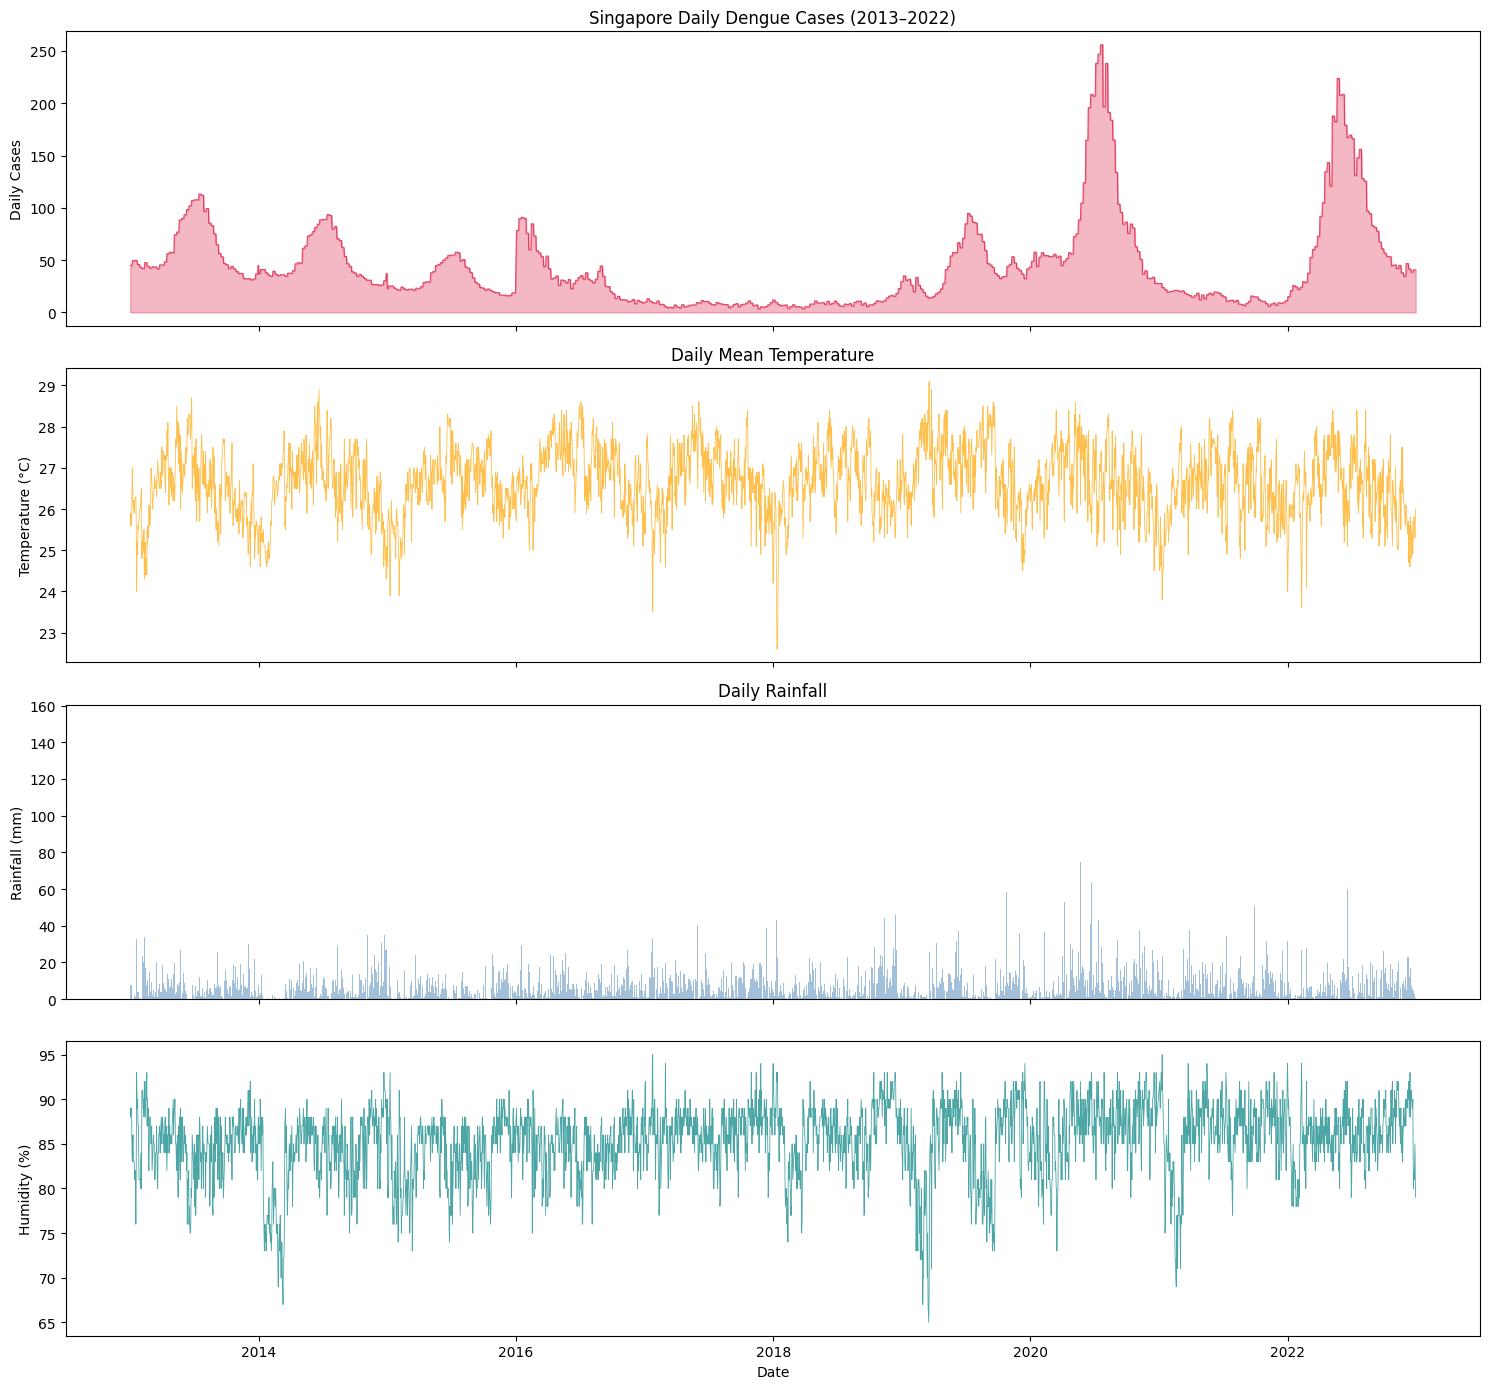

✅ Saved plots/eda_FIXED.png


In [25]:
fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)
axes[0].plot(df_raw['date'], df_raw['dengue_cases'], color='crimson', alpha=0.7, lw=0.8)
axes[0].fill_between(df_raw['date'], df_raw['dengue_cases'], alpha=0.3, color='crimson')
axes[0].set_ylabel('Daily Cases'); axes[0].set_title('Singapore Daily Dengue Cases (2013–2022)')
axes[1].plot(df_raw['date'], df_raw['temperature'], color='orange', alpha=0.7, lw=0.6)
axes[1].set_ylabel('Temperature (°C)'); axes[1].set_title('Daily Mean Temperature')
axes[2].bar(df_raw['date'], df_raw['rainfall'], color='steelblue', alpha=0.5, width=1)
axes[2].set_ylabel('Rainfall (mm)'); axes[2].set_title('Daily Rainfall')
axes[3].plot(df_raw['date'], df_raw['humidity'], color='teal', alpha=0.7, lw=0.6)
axes[3].set_ylabel('Humidity (%)'); axes[3].set_xlabel('Date')
plt.tight_layout()
plt.savefig('plots/eda_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved plots/eda_FIXED.png")


In [26]:
print("="*70)
print("  SUMMARY — Data Preprocessing & Feature Engineering Analysis")
print("="*70)
print(f"Raw data: {len(df_raw)} days x {len(df_raw.columns)} columns, 0 missing values")
print(f"Engineered: {len(df_enhanced)} days x {len(all_features)} features (60 incl. dengue_cases/date/year-excluded)")
print(f"Outliers: kept deliberately (genuine outbreak signal), handled via RobustScaler not removal")
print(f"Split: chronological 80/20, train={len(train_df)}, test={len(test_df)}")
print(f"Feature selection: RF/feature-branch={len(rf_features)} (fair, no case history), "
      f"DL sequence={len(dl_seq_features)} (full, incl. case history)")
print(f"\n✅ processed_data/canonical_data.pkl is the single dataset every other notebook (08-14) uses.")


  SUMMARY — Data Preprocessing & Feature Engineering Analysis
Raw data: 3652 days x 18 columns, 0 missing values
Engineered: 3611 days x 60 features (60 incl. dengue_cases/date/year-excluded)
Outliers: kept deliberately (genuine outbreak signal), handled via RobustScaler not removal
Split: chronological 80/20, train=2888, test=723
Feature selection: RF/feature-branch=44 (fair, no case history), DL sequence=60 (full, incl. case history)

✅ processed_data/canonical_data.pkl is the single dataset every other notebook (08-14) uses.


In [27]:
# ── [ADDED] Data Preprocessing Analysis → result tables (rubric analysis #1) ──
# Reproducible from df_raw (raw benchmark dataset loaded above). Saves quantitative preprocessing results.
import pandas as _pd, numpy as _np
_num=df_raw.select_dtypes(include=[_np.number]).columns.tolist(); _rows=[]
for _c in _num:
    _s=df_raw[_c]; _q1,_q3=_s.quantile(.25),_s.quantile(.75); _iqr=_q3-_q1
    _out=int(((_s<_q1-1.5*_iqr)|(_s>_q3+1.5*_iqr)).sum())
    _rows.append({'column':_c,'n':int(_s.notna().sum()),'missing':int(_s.isna().sum()),'missing_pct':round(_s.isna().mean()*100,2),
                  'min':round(float(_s.min()),2),'mean':round(float(_s.mean()),2),'max':round(float(_s.max()),2),
                  'std':round(float(_s.std()),2),'outliers_IQR':_out,'outlier_pct':round(_out/len(_s)*100,2)})
_pre=_pd.DataFrame(_rows); _pre.to_csv('metrics/preprocessing_summary.csv',index=False)
_t=df_raw['dengue_cases']
_imb=_pd.DataFrame([{'metric':'zero-case days','value':f"{int((_t==0).sum())} ({(_t==0).mean()*100:.1f}%)"},
 {'metric':'mean cases/day','value':round(float(_t.mean()),1)},{'metric':'median cases/day','value':round(float(_t.median()),1)},
 {'metric':'max cases/day','value':round(float(_t.max()),1)},{'metric':'skewness (right-skew)','value':round(float(_t.skew()),2)},
 {'metric':'coefficient of variation','value':round(float(_t.std()/_t.mean()),2)}])
_imb.to_csv('metrics/target_distribution_summary.csv',index=False)
print("OK saved metrics/preprocessing_summary.csv + target_distribution_summary.csv")
print(_pre.to_string(index=False)); print(); print(_imb.to_string(index=False))


OK saved metrics/preprocessing_summary.csv + target_distribution_summary.csv
            column    n  missing  missing_pct     min    mean     max    std  outliers_IQR  outlier_pct
      dengue_cases 3652        0          0.0    3.43   43.79  256.00  43.28           217         5.94
       temperature 3652        0          0.0   22.60   26.66   29.10   0.83            25         0.68
   temperature_max 3652        0          0.0   23.60   29.18   35.50   1.19           106         2.90
   temperature_min 3652        0          0.0   21.60   24.68   27.70   0.92            26         0.71
          rainfall 3652        0          0.0    0.00    7.98  152.90   9.50           155         4.24
          humidity 3652        0          0.0   65.00   85.28   95.00   4.04            86         2.35
         windspeed 3652        0          0.0    2.20    8.28   20.00   2.87            42         1.15
     windspeed_max 3652        0          0.0    5.10   13.41   28.70   3.65            31 

In [28]:
# ── [ADDED] Feature Engineering / relevance-selection basis → result table (rubric analysis #2) ──
# Ranks the engineered features by mutual information + |Pearson corr| with the target — the quantitative
# basis for the fair (RF) vs full (DL) feature-set split. Reproducible from df_enhanced / all_features.
import pandas as _pd, numpy as _np
from sklearn.feature_selection import mutual_info_regression as _mireg
_X=df_enhanced[all_features].fillna(0).values; _y=df_enhanced['dengue_cases'].values
_mi=_mireg(_X,_y,random_state=42)
_corr=df_enhanced[all_features+['dengue_cases']].corr()['dengue_cases'].drop('dengue_cases')
_fr=_pd.DataFrame({'feature':all_features,'abs_pearson_corr':[round(abs(float(_corr[f])),4) for f in all_features],
                   'mutual_info':[round(float(m),4) for m in _mi]})
_fr['in_RF_fair_set']=_fr['feature'].isin(rf_features); _fr['in_DL_seq_set']=_fr['feature'].isin(dl_seq_features)
_fr=_fr.sort_values('mutual_info',ascending=False).reset_index(drop=True); _fr.insert(0,'rank',_fr.index+1)
_fr.to_csv('metrics/feature_selection_ranking.csv',index=False)
print(f"OK saved metrics/feature_selection_ranking.csv ({len(_fr)} engineered features ranked by MI + |corr|)")
print(_fr.head(15).to_string(index=False))


OK saved metrics/feature_selection_ranking.csv (60 engineered features ranked by MI + |corr|)
 rank       feature  abs_pearson_corr  mutual_info  in_RF_fair_set  in_DL_seq_set
    1  cases_lag_14            0.9564       5.4948           False           True
    2  cases_lag_28            0.8758       5.4946           False           True
    3  cases_lag_21            0.9193       5.4883           False           True
    4 cases_diff_14            0.1477       5.1880           False           True
    5   cases_max_7            0.9461       4.9189           False           True
    6  cases_max_14            0.9320       4.8354           False           True
    7  cases_max_28            0.9007       4.6867           False           True
    8  week_of_year            0.0372       3.1406            True           True
    9  cases_7d_avg            0.9943       2.7620           False           True
   10      week_sin            0.0333       2.5336            True           True
   1